# Cruz Urbina
- Final Project - Fungi Analysis
- 5/4/26



The dataset was created to develop a machine-learning algorithm for detecting and classifying Fungi images. DeFungi is a dataset for direct mycological examination of microscopic fungi images. The images are from superficial fungal infections caused by yeasts, molds, or dermatophyte fungi. The images have been manually labelled into five classes and curated with a subject matter expert assistance. The images have been cropped with automated algorithms to produce the final dataset. Aims to detect and classify fungal infections in plants or biological samples from image data.

## Optional Setup
- Install the optional package if the notebook environment does not already include it.


In [3]:
# -----------------------------
# Optional Setup
# -----------------------------
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.0 MB/s eta 0:00:00


## Import Libraries
- Load the libraries used for data exploration, preprocessing, visualization, and modeling.


In [4]:
# -----------------------------
# Import libraries
# -----------------------------
import os
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance

from lazypredict.Supervised import LazyClassifier
from lightgbm import LGBMClassifier
from sklearn.decomposition import PCA
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import NearestCentroid
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from google.colab import drive


## Configure Project Paths
- Define the project and cache directories used to save intermediate files across notebook runs.


In [5]:
# -----------------------------
# Configure Project Paths
# -----------------------------
project_dir = "/content/drive/MyDrive/ColabNotebooks/FinalProject"
cache_dir = os.path.join(project_dir, "cache")
os.makedirs(cache_dir, exist_ok=True)


## Resize Helper Function
- Create a reusable helper method for resizing images before converting them into model-ready arrays.


In [6]:
# -----------------------------
# Resize Helper Function
# -----------------------------
def resize_image(img, image_size):
    return img.resize(image_size)


## Image Path Helper Function
- Build a helper method that scans the dataset folders and returns image paths with their class labels.


In [7]:
# -----------------------------
# Image Path Helper Function
# -----------------------------
def load_image_paths(dataset_path):
    image_data = []

    for class_name in sorted(os.listdir(dataset_path)):
        class_folder = os.path.join(dataset_path, class_name)

        if not os.path.isdir(class_folder):
            continue

        for file_name in sorted(os.listdir(class_folder)):
            if file_name.lower().endswith((".jpg", ".jpeg", ".png")):
                image_data.append({
                    "image_path": os.path.join(class_folder, file_name),
                    "label": class_name
                })

    return pd.DataFrame(image_data)


## Augmentation Helper Functions
- Define helper methods for augmenting images and balancing the class distribution before preprocessing.


In [8]:
# -----------------------------
# Augmentation Helper Functions
# -----------------------------
def augment_image(img, rng):
    if rng.random() < 0.5:
        img = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)

    img = img.rotate(rng.uniform(-15, 15))
    img = ImageEnhance.Brightness(img).enhance(rng.uniform(0.9, 1.1))
    img = ImageEnhance.Contrast(img).enhance(rng.uniform(0.9, 1.1))

    return img


def build_balanced_dataframe(df):
    class_counts = df["label"].value_counts()
    target_count = class_counts.max()
    augmentation_rows = []

    for label, count in class_counts.items():
        if count >= target_count:
            continue

        class_subset = df[df["label"] == label].reset_index(drop=True)
        samples_needed = target_count - count

        for i in range(samples_needed):
            sample = class_subset.iloc[i % len(class_subset)]
            augmentation_rows.append({
                "image_path": sample["image_path"],
                "label": label,
                "is_augmented": True
            })

    df_balanced = df.copy()
    df_balanced["is_augmented"] = False

    if augmentation_rows:
        df_balanced = pd.concat(
            [df_balanced, pd.DataFrame(augmentation_rows)],
            ignore_index=True
        )

    df_balanced["is_augmented"] = df_balanced["is_augmented"].astype(bool)
    return df_balanced


## Image Array Helper Function
- Create a helper method that loads, augments, resizes, and flattens images into feature arrays and labels.


In [9]:
# -----------------------------
# Image Array Helper Function
# -----------------------------
def build_image_arrays(working_df, image_size=(32, 32), seed=42):
    X = []
    y = []
    rng = np.random.default_rng(seed)

    for row in working_df.itertuples():
        try:
            with Image.open(row.image_path) as img:
                img = img.convert("RGB")

                if getattr(row, "is_augmented", False):
                    img = augment_image(img, rng)

                img = resize_image(img, image_size)
                arr = np.asarray(img, dtype=np.float32) / 255.0

            X.append(arr.flatten())
            y.append(row.label)

        except Exception as e:
            print("Error loading:", row.image_path, e)

    return np.asarray(X, dtype=np.float32), np.asarray(y)


## Mount Google Drive
- Connect Google Drive so the notebook can access the project dataset and saved arrays.


In [12]:
# -----------------------------
# Mount Google Drive
# -----------------------------
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# -----------------------------
# Flush any mounted drives
# -----------------------------
drive.flush_and_unmount()

!rm -rf /content/drive

Drive not mounted, so nothing to flush and unmount.


## Load Image Paths
- Collect each image path and class label from the dataset folders into a dataframe.


In [13]:
# -----------------------------
# Load Image Paths
# -----------------------------

dataset_path = '/content/drive/MyDrive/ColabNotebooks/FinalProject/defungi'
image_paths_cache = os.path.join(cache_dir, "image_paths.csv")

if os.path.exists(image_paths_cache):
    df = pd.read_csv(image_paths_cache)
    print("Loaded image paths from cache.")
else:
    df = load_image_paths(dataset_path)
    df.to_csv(image_paths_cache, index=False)
    print("Loaded image paths from dataset and cached them.")


Loaded image paths from dataset and cached them.


## Preview Dataset
- Display the first few rows to confirm the image paths and labels loaded correctly.


In [14]:
# -----------------------------
# Preview Dataset
# -----------------------------
print(df.head())

                                          image_path label
0  /content/drive/MyDrive/ColabNotebooks/FinalPro...    H1
1  /content/drive/MyDrive/ColabNotebooks/FinalPro...    H1
2  /content/drive/MyDrive/ColabNotebooks/FinalPro...    H1
3  /content/drive/MyDrive/ColabNotebooks/FinalPro...    H1
4  /content/drive/MyDrive/ColabNotebooks/FinalPro...    H1


## Count Images
- Print the total number of images included in the dataset.


In [16]:
# -----------------------------
# Count Images
# -----------------------------
print("Total images:", len(df))

Total images: 9114


## List Classes
- Show the unique fungi classes present in the dataset.


In [17]:
# -----------------------------
# List Classes
# -----------------------------
print("Classes:", df["label"].unique())

Classes: ['H1' 'H2' 'H3' 'H5' 'H6']


## Display Sample Image
- Open and display one example image from the dataset.


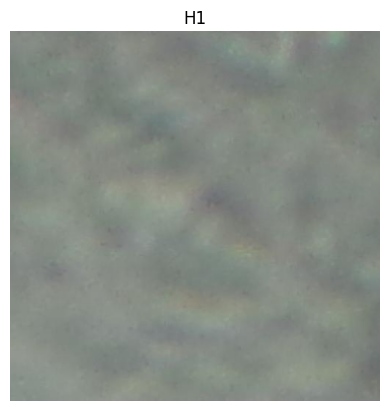

In [18]:
# -----------------------------
# Display Sample Image
# -----------------------------
class_folder = os.listdir(dataset_path)[0]
image_folder = os.path.join(dataset_path, class_folder)

image_file = os.listdir(image_folder)[0]
image_path = os.path.join(image_folder, image_file)

img = Image.open(image_path)

plt.imshow(img)
plt.title(class_folder)
plt.axis("off")
plt.show()

## Class Counts
- Count how many images belong to each fungi class.


In [19]:
# -----------------------------
# Class Counts
# -----------------------------
class_counts = df["label"].value_counts()
print(class_counts)

label
H1    4404
H2    2334
H3     819
H5     818
H6     739
Name: count, dtype: int64


## Class Percentages
- Calculate the percentage of samples represented by each class.


In [20]:
# -----------------------------
# Class Percentages
# -----------------------------
class_percentages = df["label"].value_counts(normalize=True) * 100
print(class_percentages)

label
H1    48.321264
H2    25.608953
H3     8.986175
H5     8.975203
H6     8.108405
Name: proportion, dtype: float64


## Sample Images By Class
- Display one example image for each fungi class to compare them visually.


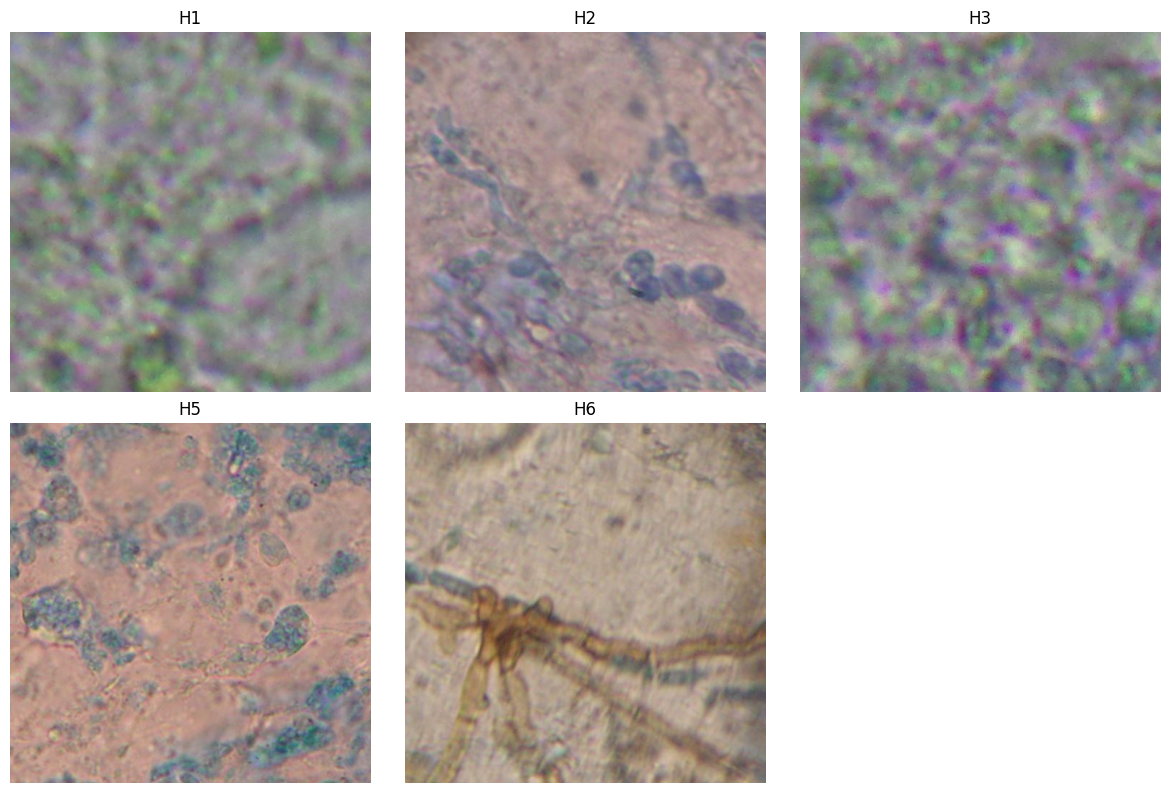

In [21]:
# -----------------------------
# Sample Images By Class
# -----------------------------

plt.figure(figsize=(12,8))

for i, label in enumerate(df["label"].unique()):
    sample_path = df[df["label"] == label]["image_path"].iloc[0]
    img = Image.open(sample_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Plot Class Balance
- Visualize the class distribution to check whether the dataset is balanced.


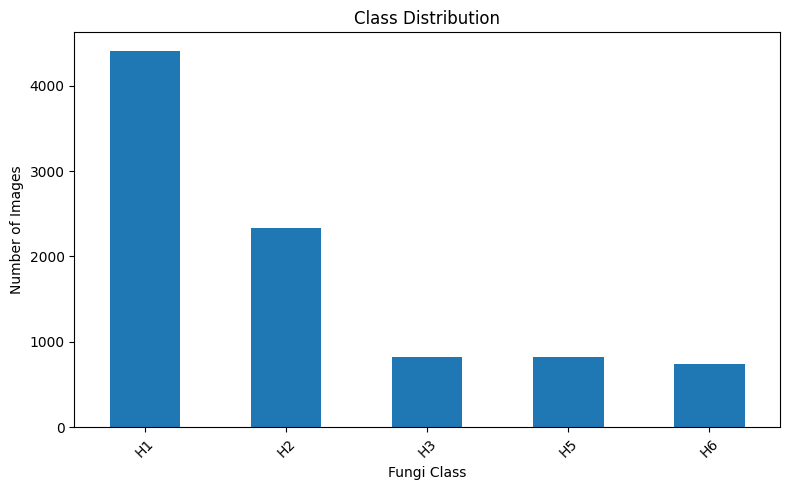

In [22]:
# -----------------------------
# Plot Class Balance
# -----------------------------
plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Fungi Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Augment Minority Classes
- Create additional training examples for minority classes so the model sees a more balanced class distribution.


In [23]:
# -----------------------------
# Augment Minority Classes
# -----------------------------
balanced_cache_path = os.path.join(cache_dir, "balanced_image_paths.csv")

if os.path.exists(balanced_cache_path):
    df_balanced = pd.read_csv(balanced_cache_path)
    df_balanced["is_augmented"] = df_balanced["is_augmented"].astype(bool)
    print("Loaded balanced dataset from cache.")
else:
    df_balanced = build_balanced_dataframe(df)
    df_balanced.to_csv(balanced_cache_path, index=False)
    print("Built balanced dataset and cached it.")

print(df_balanced["label"].value_counts())


Built balanced dataset and cached it.
label
H1    4404
H2    4404
H3    4404
H5    4404
H6    4404
Name: count, dtype: int64


## Prepare Image Arrays
- Resize the images and convert them into flattened normalized arrays for modeling.


In [24]:
# -----------------------------
# Prepare Image Arrays
# -----------------------------
image_size = (32, 32)
processed_path = os.path.join(cache_dir, "defungi_processed_augmented.npz")

if os.path.exists(processed_path):
    data = np.load(processed_path)
    X = data["X"]
    y = data["y"]
    print("Loaded processed image arrays from cache.")
else:
    working_df = df_balanced if "df_balanced" in globals() else df.copy()
    X, y = build_image_arrays(working_df, image_size=image_size)
    np.savez_compressed(processed_path, X=X, y=y)
    print("Built processed image arrays and cached them.")

print("X shape:", X.shape)
print("y shape:", y.shape)


Loaded processed image arrays from cache.
X shape: (22020, 3072)
y shape: (22020,)


## Load Processed Data
- Load the saved feature and label arrays instead of regenerating them each time.


In [25]:
# -----------------------------
# Load Processed Data
# -----------------------------
candidate_processed_paths = [
    os.path.join(cache_dir, "defungi_processed_augmented.npz"),
    os.path.join(cache_dir, "defungi_processed.npz")
]

if "X" in globals() and "y" in globals():
    print("Processed arrays already available.")
else:
    processed_path = next(
        (path for path in candidate_processed_paths if os.path.exists(path)),
        None
    )

    if processed_path is None:
        raise FileNotFoundError("No processed dataset cache was found.")

    data = np.load(processed_path)
    X = data["X"]
    y = data["y"]
    print("Loaded:", processed_path)

print(X.shape, y.shape)


Processed arrays already available.
(22020, 3072) (22020,)


## Encode Labels
- Convert the class labels into numeric values for the machine learning models.


In [26]:
# -----------------------------
# Encode Labels
# -----------------------------
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

Classes: ['H1' 'H2' 'H3' 'H5' 'H6']


## Split Training Data
- Create the training set and hold out the remaining data for validation and testing.


In [27]:
# -----------------------------
# Split Training Data
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

## Split Validation And Test Data
- Divide the remaining samples equally into validation and test sets.


In [28]:
# -----------------------------
# Split Validation And Test Data
# -----------------------------
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

## Check Split Shapes
- Print the shape of each split to verify the dataset partitions.


In [29]:
# -----------------------------
# Check Split Shapes
# -----------------------------
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (17616, 3072)
Validation: (2202, 3072)
Test: (2202, 3072)


## Scale Features
- Standardize the feature values before dimensionality reduction and model training.


In [30]:
# -----------------------------
# Scale Features
# -----------------------------
scaled_cache_path = os.path.join(cache_dir, "scaled_splits.joblib")

if os.path.exists(scaled_cache_path):
    scaled_cache = joblib.load(scaled_cache_path)
    scaler = scaled_cache["scaler"]
    X_train_scaled = scaled_cache["X_train_scaled"]
    X_val_scaled = scaled_cache["X_val_scaled"]
    X_test_scaled = scaled_cache["X_test_scaled"]
    print("Loaded scaled feature splits from cache.")
else:
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    joblib.dump({
        "scaler": scaler,
        "X_train_scaled": X_train_scaled,
        "X_val_scaled": X_val_scaled,
        "X_test_scaled": X_test_scaled
    }, scaled_cache_path)
    print("Built scaled feature splits and cached them.")


Built scaled feature splits and cached them.


## Apply PCA
- Reduce the feature space while preserving most of the variance in the data.


In [31]:
# -----------------------------
# Apply PCA
# -----------------------------
pca_cache_path = os.path.join(cache_dir, "pca_splits.joblib")

if os.path.exists(pca_cache_path):
    pca_cache = joblib.load(pca_cache_path)
    pca = pca_cache["pca"]
    X_train_pca = pca_cache["X_train_pca"]
    X_val_pca = pca_cache["X_val_pca"]
    X_test_pca = pca_cache["X_test_pca"]
    print("Loaded PCA-transformed splits from cache.")
else:
    pca = PCA(n_components=0.95)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    joblib.dump({
        "pca": pca,
        "X_train_pca": X_train_pca,
        "X_val_pca": X_val_pca,
        "X_test_pca": X_test_pca
    }, pca_cache_path)
    print("Built PCA-transformed splits and cached them.")


Built PCA-transformed splits and cached them.


## Compare Dimensions
- Print the original and reduced feature dimensions after PCA.


In [32]:
# -----------------------------
# Compare Dimensions
# -----------------------------
print("Train")
print("Original shape:", X_train.shape)
print("Reduced shape:", X_train_pca.shape)

print("Test")
print("Original shape:", X_test.shape)
print("Reduced shape:", X_test_pca.shape)

Train
Original shape: (17616, 3072)
Reduced shape: (17616, 425)
Test
Original shape: (2202, 3072)
Reduced shape: (2202, 425)


## Run Baseline Models
- Benchmark many classifiers quickly to identify strong candidates.


In [ ]:
# -----------------------------
# Run Baseline Models
# -----------------------------
baseline_models_path = os.path.join(cache_dir, "baseline_models.csv")

if os.path.exists(baseline_models_path):
    models = pd.read_csv(baseline_models_path, index_col=0)
    print("Loaded cached baseline model results.")
else:
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
    models, predictions = clf.fit(
        X_train_pca,
        X_test_pca,
        y_train,
        y_test
    )
    models.to_csv(baseline_models_path)
    print("Built baseline model results and cached them.")

models.head(10)


Built baseline model results and cached them.


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
XGBClassifier,0.769755,0.769669,0.944447,0.761679,0.766521,0.769755,135.347808
LGBMClassifier,0.754768,0.754686,0.939515,0.746215,0.749812,0.754768,70.102291
RandomForestClassifier,0.691644,0.691553,0.900703,0.680680,0.682375,0.691644,92.312657
NuSVC,0.690282,0.690205,NaN,0.685561,0.692955,0.690282,284.439598
SVC,0.672570,0.672484,NaN,0.664824,0.672717,0.672570,233.355635
BaggingClassifier,0.648955,0.648896,0.880845,0.645601,0.646232,0.648955,196.352830
QuadraticDiscriminantAnalysis,0.648955,0.648867,0.881547,0.652959,0.658313,0.648955,2.218498
ExtraTreesClassifier,0.639873,0.639786,0.880296,0.630707,0.629312,0.639873,18.038338
DecisionTreeClassifier,0.592189,0.592168,0.745126,0.593042,0.594163,0.592189,28.534345


## Show Top Baseline Models
- Render the top baseline model results as a table and save the figure.


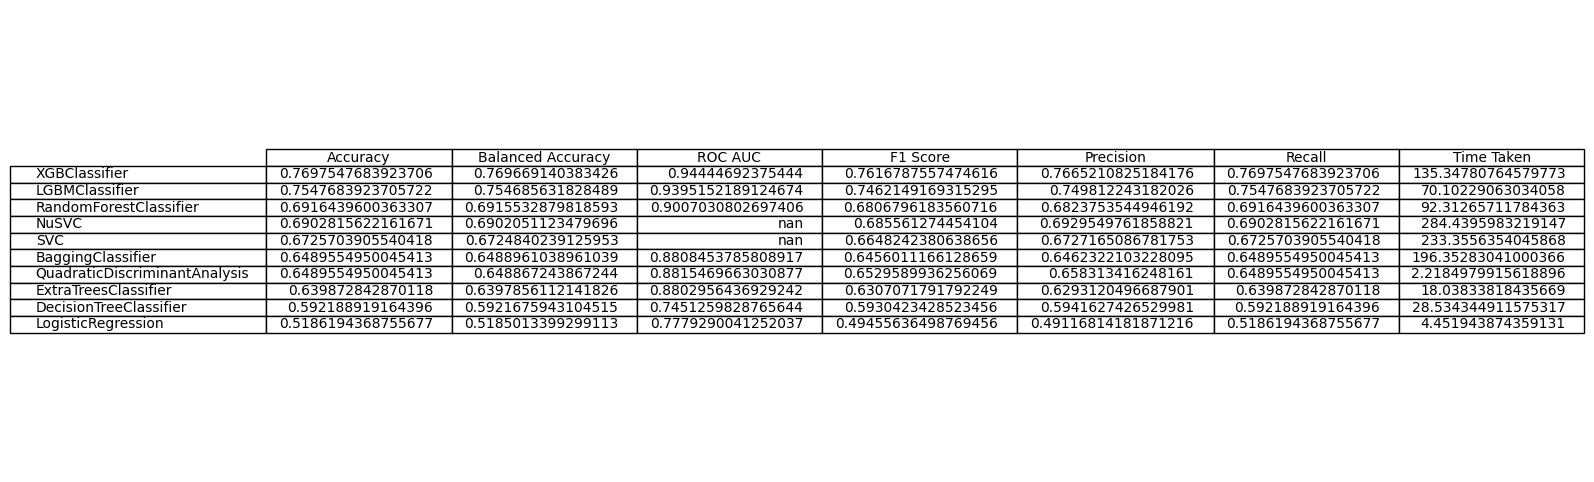

In [ ]:
# -----------------------------
# Show Top Baseline Models
# -----------------------------
top_models = models.head(10)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Hide axes
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(
    cellText=top_models.values,
    colLabels=top_models.columns,
    rowLabels=top_models.index,
    loc='center'
)

# Adjust table formatting
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(top_models.columns))))

# Save as JPG
plt.savefig("top_models.jpg", bbox_inches='tight', dpi=300)

plt.show()

## Define Tuning Search Space
- Set up the top models and hyperparameter ranges for randomized tuning.


In [ ]:
# -----------------------------
# Define Tuning Search Space
# -----------------------------
top6_models = {
    "LGBMClassifier": {
        "model": LGBMClassifier(
            random_state=42,
            class_weight="balanced",
            n_jobs=1,
            verbosity=-1
        ),
        "params": {
            "n_estimators": [50, 100],
            "learning_rate": [0.05, 0.1],
            "max_depth": [-1, 10],
            "num_leaves": [31]
        },
        "n_iter": 4
    },

    "XGBClassifier": {
        "model": XGBClassifier(
            random_state=42,
            eval_metric="mlogloss",
            tree_method="hist",
            n_jobs=1
        ),
        "params": {
            "n_estimators": [50, 100],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 6],
            "subsample": [0.8]
        },
        "n_iter": 4
    },

    "RandomForestClassifier": {
        "model": RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_jobs=1
        ),
        "params": {
            "n_estimators": [50, 100],
            "max_depth": [10, 20],
            "min_samples_split": [2, 5]
        },
        "n_iter": 4
    },

    "DecisionTreeClassifier": {
        "model": DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        ),
        "params": {
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2]
        },
        "n_iter": 4
    },

    "NearestCentroid": {
        "model": NearestCentroid(),
        "params": {
            "metric": ["euclidean", "manhattan"]
        },
        "n_iter": 2
    },

    "BaggingClassifier": {
        "model": BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=10, random_state=42),
            random_state=42,
            n_jobs=1
        ),
        "params": {
            "n_estimators": [10, 25],
            "max_samples": [0.7],
            "max_features": [0.7]
        },
        "n_iter": 2
    }
}

## Tune Candidate Models
- Perform randomized cross-validated tuning for each selected model.


In [ ]:
# -----------------------------
# Tune Candidate Models
# -----------------------------
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

tuned_results_path = os.path.join(cache_dir, "tuned_results.csv")
best_estimators_path = os.path.join(cache_dir, "best_estimators.joblib")

if os.path.exists(tuned_results_path) and os.path.exists(best_estimators_path):
    tuned_results_df = pd.read_csv(tuned_results_path)
    best_estimators = joblib.load(best_estimators_path)
    print("Loaded cached tuned model results.")
else:
    tuned_results = []
    best_estimators = {}

    for name, config in top6_models.items():
        print(f"\nTuning {name}...")
        start = time.time()

        search = RandomizedSearchCV(
            estimator=config["model"],
            param_distributions=config["params"],
            n_iter=config["n_iter"],
            scoring="f1_weighted",
            cv=cv,
            n_jobs=2,
            verbose=1,
            random_state=42
        )

        search.fit(X_train_pca, y_train)

        elapsed = round((time.time() - start) / 60, 2)
        best_estimators[name] = search.best_estimator_

        tuned_results.append({
            "Model": name,
            "Best CV F1 Weighted": search.best_score_,
            "Best Params": str(search.best_params_),
            "Minutes": elapsed
        })

    tuned_results_df = pd.DataFrame(tuned_results).sort_values(
        by="Best CV F1 Weighted",
        ascending=False
    )

    tuned_results_df.to_csv(tuned_results_path, index=False)
    joblib.dump(best_estimators, best_estimators_path)
    print("Saved tuned model cache.")

tuned_results_df

Loaded cached tuned model results.


,Model,Best CV F1 Weighted,Best Params,Minutes
0,LGBMClassifier,0.733883,"{'num_leaves': 31, 'n_estimators': 100, 'max_d...",9.07
1,XGBClassifier,0.711284,"{'subsample': 0.8, 'n_estimators': 100, 'max_d...",9.39
2,RandomForestClassifier,0.644798,"{'n_estimators': 100, 'min_samples_split': 5, ...",6.82
3,BaggingClassifier,0.617703,"{'n_estimators': 25, 'max_samples': 0.7, 'max_...",7.18
4,DecisionTreeClassifier,0.577734,"{'min_samples_split': 2, 'min_samples_leaf': 1...",2.60
5,NearestCentroid,0.463814,{'metric': 'euclidean'},0.02


## Evaluate Tuned Models
- Measure the tuned models on the test set using weighted classification metrics.


In [ ]:
# -----------------------------
# Evaluate Tuned Models
# -----------------------------
test_results_path = os.path.join(cache_dir, "test_results.csv")

if os.path.exists(test_results_path):
    test_results_df = pd.read_csv(test_results_path)
    print("Loaded cached test results.")
else:
    test_results = []

    for name, model in best_estimators.items():
        y_pred = model.predict(X_test_pca)

        report = classification_report(
            y_test,
            y_pred,
            output_dict=True,
            zero_division=0
        )

        test_results.append({
            "Model": name,
            "Accuracy": report["accuracy"],
            "Precision Weighted": report["weighted avg"]["precision"],
            "Recall Weighted": report["weighted avg"]["recall"],
            "F1 Weighted": report["weighted avg"]["f1-score"]
        })

    test_results_df = pd.DataFrame(test_results).sort_values(
        by="F1 Weighted",
        ascending=False
    )
    test_results_df.to_csv(test_results_path, index=False)
    print("Saved test results cache.")

test_results_df

Loaded cached test results.


,Model,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted
0,LGBMClassifier,0.759764,0.755631,0.759764,0.753008
1,XGBClassifier,0.739782,0.738670,0.739782,0.728793
2,RandomForestClassifier,0.679837,0.671623,0.679837,0.659947
3,BaggingClassifier,0.655313,0.649916,0.655313,0.628388
4,DecisionTreeClassifier,0.612171,0.613491,0.612171,0.603593
5,NearestCentroid,0.473660,0.469898,0.473660,0.458729


## Table 1. Tuned Model Performance
- Merge cross-validated training performance with held-out test metrics for report-ready comparison.


In [ ]:
# -----------------------------
# Table 1: Tuned Model Performance
# -----------------------------
table1_df = tuned_results_df[["Model", "Best CV F1 Weighted"]].merge(
    test_results_df,
    on="Model",
    how="inner"
)

table1_df = table1_df.rename(columns={
    "Best CV F1 Weighted": "Training CV F1 Weighted",
    "Accuracy": "Test Accuracy",
    "Precision Weighted": "Test Precision Weighted",
    "Recall Weighted": "Test Recall Weighted",
    "F1 Weighted": "Test F1 Weighted"
})

table1_df = table1_df[[
    "Model",
    "Training CV F1 Weighted",
    "Test Accuracy",
    "Test Precision Weighted",
    "Test Recall Weighted",
    "Test F1 Weighted"
]]

numeric_cols = table1_df.columns[1:]
table1_df[numeric_cols] = table1_df[numeric_cols].round(4)

display(table1_df)

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.axis("tight")
ax.axis("off")

table = ax.table(
    cellText=table1_df.values,
    colLabels=table1_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.15, 1.5)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#dbeafe")

plt.title("Table 1. Performance of Tuned Models on Training and Test Data", pad=16)
plt.savefig("table1_tuned_model_performance.png", bbox_inches="tight", dpi=300)
plt.show()


## Show Test Results
- Display the tuned model performance table and save it as an image.


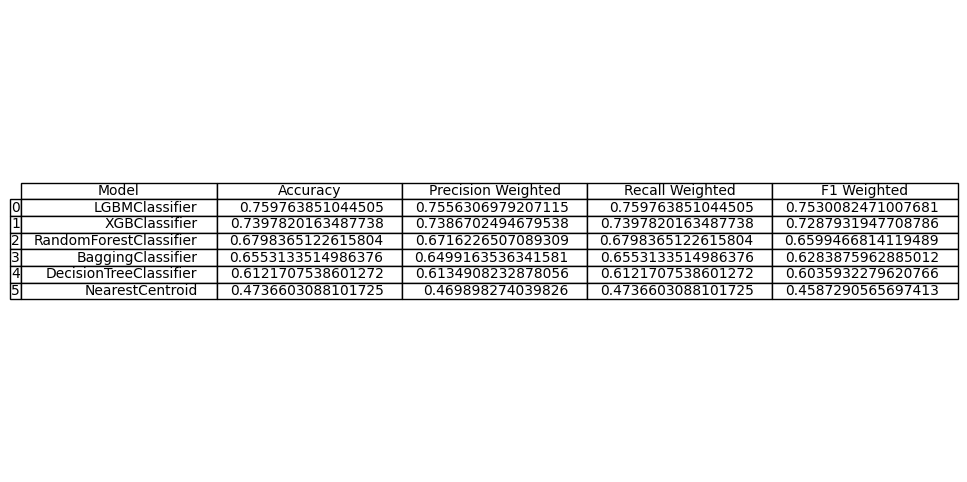

In [ ]:
# -----------------------------
# Show Test Results
# -----------------------------
test_results = test_results_df

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# Hide axes
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(
    cellText=test_results.values,
    colLabels=test_results.columns,
    rowLabels=test_results.index,
    loc='center'
)

# Adjust table formatting
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(test_results.columns))))

# Save as JPG
plt.savefig("test_results.jpg", bbox_inches='tight', dpi=300)

plt.show()

## Plot Test Metric Comparison
- Compare the tuned models across the main weighted test metrics with a grouped bar chart.


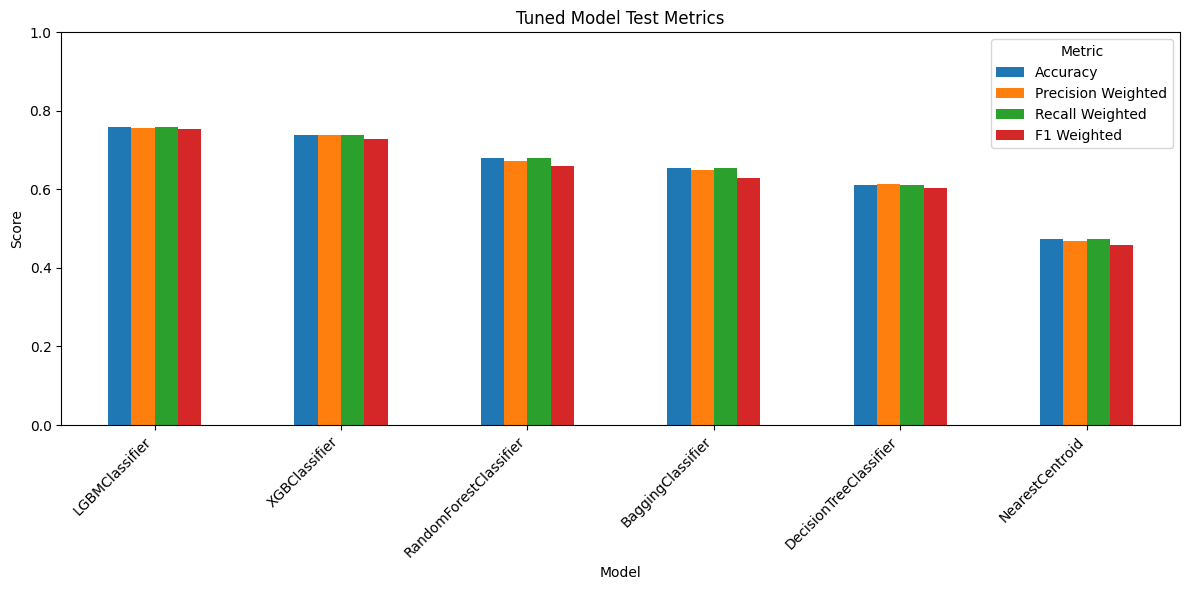

In [ ]:
# -----------------------------
# Plot Test Metric Comparison
# -----------------------------
metric_columns = [
    "Accuracy",
    "Precision Weighted",
    "Recall Weighted",
    "F1 Weighted"
]

plot_df = test_results_df.set_index("Model")[metric_columns]
ax = plot_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("Tuned Model Test Metrics")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


## Compare CV And Test F1
- Show how each tuned model performed during cross-validation versus on the held-out test set.


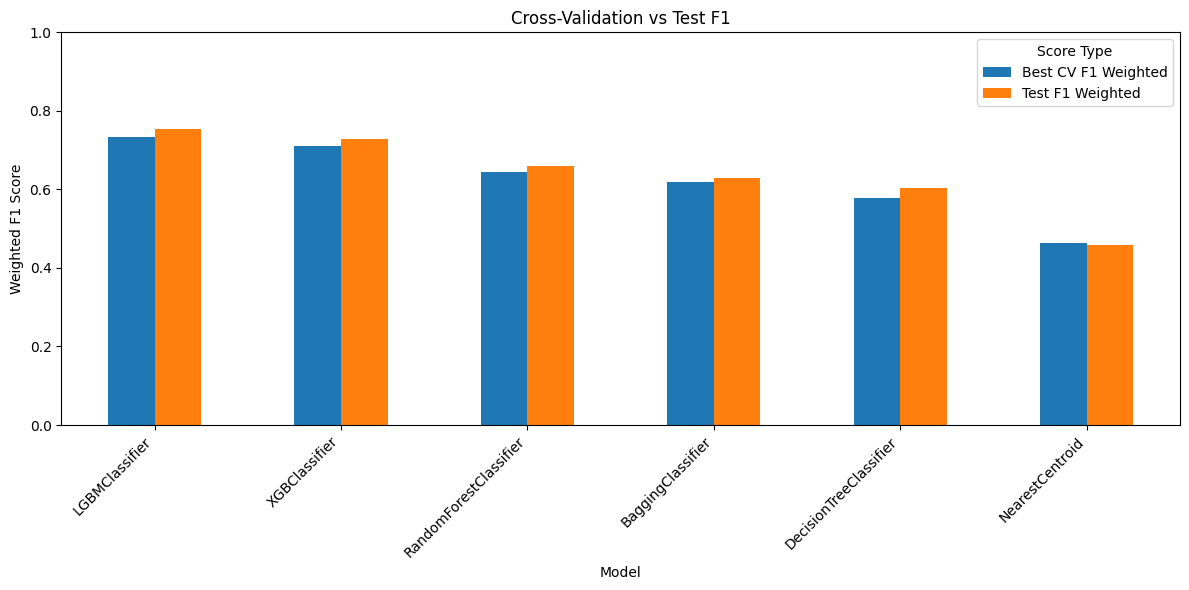

In [ ]:
# -----------------------------
# Compare CV And Test F1
# -----------------------------
comparison_df = tuned_results_df[["Model", "Best CV F1 Weighted"]].merge(
    test_results_df[["Model", "F1 Weighted"]],
    on="Model"
)

comparison_df = comparison_df.rename(
    columns={"F1 Weighted": "Test F1 Weighted"}
)

comparison_df = comparison_df.set_index("Model")
ax = comparison_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("Cross-Validation vs Test F1")
ax.set_xlabel("Model")
ax.set_ylabel("Weighted F1 Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Score Type")
plt.tight_layout()
plt.show()


## Select Best Model
- Identify the best-performing tuned model from the ranked results.


In [ ]:
# -----------------------------
# Select Best Model
# -----------------------------
best_model_name = test_results_df.iloc[0]["Model"]
best_model_path = os.path.join(cache_dir, f"{best_model_name}_best_model.joblib")

if os.path.exists(best_model_path):
    best_model = joblib.load(best_model_path)
    print("Loaded cached best model.")
else:
    best_model = best_estimators[best_model_name]
    joblib.dump(best_model, best_model_path)
    print("Saved best model to cache.")

print("Best Model:", best_model_name)
print(best_model)
print("Path:", best_model_path)


Loaded cached best model.
Best Model: LGBMClassifier
LGBMClassifier(class_weight='balanced', n_jobs=1, random_state=42, verbosity=-1)
Path: /content/drive/MyDrive/ColabNotebooks/FinalProject/cache/LGBMClassifier_best_model.joblib


## Classification Report
- Generate the detailed classification report for the best model.


In [ ]:
# -----------------------------
# Classification Report
# -----------------------------
best_predictions_path = os.path.join(cache_dir, f"{best_model_name}_predictions.npz")

if os.path.exists(best_predictions_path):
    prediction_data = np.load(best_predictions_path, allow_pickle=True)
    y_pred_best = prediction_data["y_pred_best"]
    print("Loaded cached predictions.")
else:
    y_pred_best = best_model.predict(X_test_pca)
    np.savez_compressed(best_predictions_path, y_pred_best=y_pred_best)
    print("Saved cached predictions.")

print(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoder.classes_,
    zero_division=0
))

Loaded cached predictions.
              precision    recall  f1-score   support

          H1       0.72      0.89      0.80       441
          H2       0.64      0.47      0.54       440
          H3       0.70      0.74      0.72       440
          H5       0.83      0.79      0.81       441
          H6       0.88      0.91      0.90       440

    accuracy                           0.76      2202
   macro avg       0.76      0.76      0.75      2202
weighted avg       0.76      0.76      0.75      2202



## Plot Class-Level Metrics
- Visualize precision, recall, and F1-score for each class in the best-performing model.


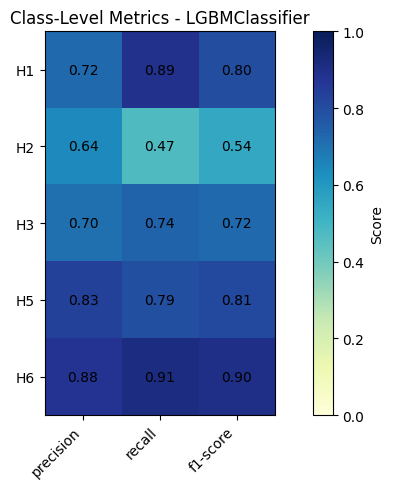

In [ ]:
# -----------------------------
# Plot Class-Level Metrics
# -----------------------------
best_report = pd.DataFrame(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)).T

class_metric_df = best_report.loc[label_encoder.classes_, [
    "precision",
    "recall",
    "f1-score"
]]

fig, ax = plt.subplots(figsize=(8, 5))
heatmap = ax.imshow(class_metric_df.values, cmap="YlGnBu", vmin=0, vmax=1)

ax.set_xticks(range(len(class_metric_df.columns)))
ax.set_xticklabels(class_metric_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(class_metric_df.index)))
ax.set_yticklabels(class_metric_df.index)
ax.set_title(f"Class-Level Metrics - {best_model_name}")

for i in range(class_metric_df.shape[0]):
    for j in range(class_metric_df.shape[1]):
        ax.text(j, i, f"{class_metric_df.iloc[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(heatmap, ax=ax, label="Score")
plt.tight_layout()
plt.show()


## Confusion Matrices
- Plot both raw-count and normalized confusion matrices to compare overall errors and class-level recall fairly.


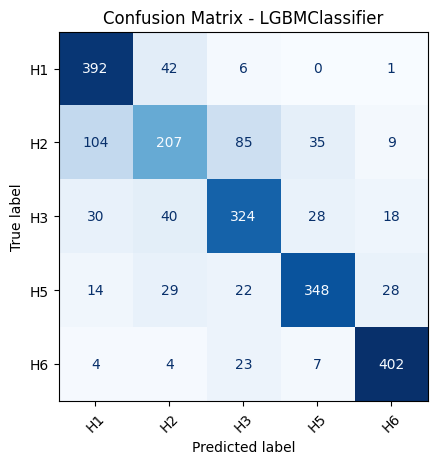

In [ ]:
# -----------------------------
# Confusion Matrices
# -----------------------------
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
).plot(xticks_rotation=45, cmap="Blues", colorbar=False)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

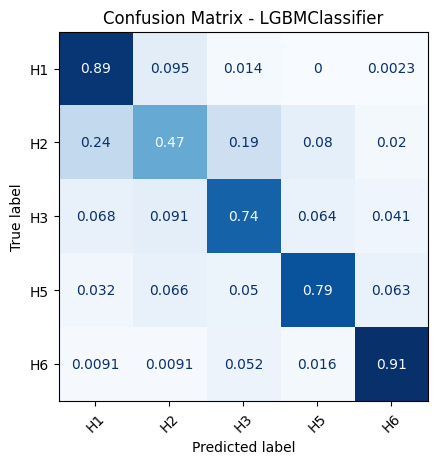

In [ ]:
# -----------------------------
# Confusion Matrices
# -----------------------------
cm_normalized = confusion_matrix(y_test, y_pred_best, normalize="true")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=label_encoder.classes_
).plot(xticks_rotation=45, cmap="Blues", colorbar=False)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## Configure LightGBM Search
- Create a focused LightGBM model and parameter distribution for additional tuning.


In [ ]:
# -----------------------------
# Configure LightGBM Search
# -----------------------------
lgbm = LGBMClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=1,
    verbosity=-1
)

param_dist = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [-1, 5, 10],
    "num_leaves": [31, 50, 70]
}

## Run LightGBM Search
- Execute randomized hyperparameter tuning for the LightGBM classifier.


In [ ]:
# -----------------------------
# Run LightGBM Search
# -----------------------------
lgbm_search_path = os.path.join(cache_dir, "lightgbm_search.joblib")

if os.path.exists(lgbm_search_path):
    search = joblib.load(lgbm_search_path)
    print("Loaded cached LightGBM search.")
else:
    search = RandomizedSearchCV(
        lgbm,
        param_dist,
        n_iter=10,
        scoring="f1_weighted",
        cv=3,
        n_jobs=2,
        verbose=1,
        random_state=42
    )

    search.fit(X_train_pca, y_train)
    joblib.dump(search, lgbm_search_path)
    print("Saved cached LightGBM search.")

Loaded cached LightGBM search.


## Review Best LightGBM Model
- Print the best LightGBM parameters and cross-validation score.


In [ ]:
# -----------------------------
# Review Best LightGBM Model
# -----------------------------
best_lgbm = search.best_estimator_

print(search.best_params_)
print(search.best_score_)

{'num_leaves': 50, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
0.7392095858964786
